# Reproducing the beyond-EdS full-kernel correction figure

This notebook reproduces `examples/example.png` (the paper's *"Effect of the
beyond-EdS kernels and growth corrections implemented in `fkpt` on the power
spectrum multipoles"* figure), with one change relative to how that figure was
originally produced: **every beyond-EdS curve here uses the genuine, full
(non-squeezed) kernels** (`beyond_eds=True, fkpt_approximation=False`), not the
fkPT large-scale-limit approximation. Concretely, for each of the figure's five
MG models we compute

$$
\frac{\Delta P_\ell}{P_\ell} = \frac{P_\ell^{\rm full} - P_\ell^{\rm EdS}}{P_\ell^{\rm EdS}}
$$

for $\ell = 0, 2, 4$, where $P_\ell^{\rm EdS}$ (`beyond_eds=False`) keeps the
one-loop kernels in their standard EdS form (only the linear growth carries
the MG signal) and $P_\ell^{\rm full}$ (`beyond_eds=True,
fkpt_approximation=False`) uses the real, non-squeezed
$(k,q,\mathrm{angle})$-dependent $\mathcal{A}/\mathcal{B}$ kernels from
`fkptjax.MG_kernels`.

We also add the **neutrino-correction case** the original figure shows as
dashed-dotted curves: the same $\Delta P_\ell/P_\ell$, but computed with a
massive-neutrino correction to the internal growth ODE and using $P_{cb}$
(rather than total matter $P_m$) as the input linear spectrum, mirroring
`examples/test_neutrino_kernels.ipynb`'s neutrino setup.

**Library change needed for this notebook**: the direct JAX route
(`Kfuncs_to_tables_jax`, used by `fkptjax.pipelines.binning_jax_poles`) has no
`neutrino_correction` argument, so it cannot produce the neutrino-corrected
full-kernel curves. Instead, this notebook uses the legacy/eager
`fkptjax.kfuncs_to_tables.Kfuncs_to_tables`, which already accepted
`neutrino_correction` but, until now, always used the fkPT large-scale-limit
approximation whenever `beyond_eds=True`. `Kfuncs_to_tables` now also accepts
`fkpt_approximation` (default `True`, unchanged historical behavior);
`fkpt_approximation=False` computes the same genuine full-kernel Q/R/N grid
`Kfuncs_to_tables_jax` does (via `fkptjax.MG_kernels.I1udd1_and_P13_grid`), so
it can be combined with `neutrino_correction`. For a scale-independent model
the two flags still agree to solver tolerance (verified below), exactly as
they already did on the JAX route.

**Grid resolution caveat** (see `compute_mg_multipoles.ipynb`'s beyond-EdS
section for the full discussion): the full-kernel path solves one ODE per
(loop-$q$, angle, $k$) grid point, so this notebook uses a deliberately modest
shared quadrature grid to finish in a reasonable time. For a publication-
quality reproduction, increase `NK_KERNEL`/`NQUAD_STEPS`/`NQ`/`NR` below (and
rerun on a compute node, not an interactive login/OOD shell).

In [3]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

print("cwd:", cwd)
print("python:", sys.executable)

cwd: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples
python: /n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/bin/python


In [4]:
import time

import numpy as np
np.int = int  # ISiTGR compatibility with recent NumPy

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import folps as folpsv2
from cosmoprimo.fiducial import DESI

from fkptjax.neutrinos import NeutrinoTransferCorrection
from fkptjax.rsd import pack_fkpt_bias
from fkptjax.kfuncs_to_tables import Kfuncs_to_tables

print("jax:", jax.__version__)
print("devices:", jax.devices())

/n/home12/cgarciaquintero/DESI/src/Triumvirate/src/triumvirate/winconv.py:89: ExperimentalWarning: The `triumvirate.winconv` module is currently experimental. Its behaviour has not been fully tested and may change in the future.
  warnings.warn(
Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^

⚠️ JAX is using CPU. Devices: [CpuDevice(id=0)]
jax: 0.9.1
devices: [CpuDevice(id=0)]


## Configuration

$z=0.3$, $m_\nu = 0.10\,{\rm eV}$ -- same neutrino mass as
`test_neutrino_kernels.ipynb`, evaluated at the redshift used by
`compute_mg_multipoles.ipynb`'s own beyond-EdS comparison section.

In [5]:
Z = 0.3
# eV; validation run, effectively massless -- set to 0.1 (or your preferred mass) later.
# CAMB rejects a literal 0.0 here with N_NCDM=1 ("Nu_mass_fractions do not add up to 1" --
# it can't mass-weight a fraction when the total mass is exactly zero), so use a tiny
# nonzero placeholder instead; numerically indistinguishable from massless for this check.
MNU = 0.2
N_UR = 2.0308
N_NCDM = 1

KMIN_LIN = 1.0e-3
KMAX_LIN = 1.0
KMIN_PLOT = 0.02
KMAX_PLOT = 0.20

XNOW = -3.912023  # ln(a_init)

ELLS = (0, 2, 4)

# Deliberately modest shared quadrature grid -- see the grid-resolution
# caveat above. Increase for a converged, publication-quality reproduction.
NK_KERNEL = 20
NQUAD_STEPS = 48
NQ = 6
NR = 6
NMU = 8
NK_PLOT = 40

## Cosmology, linear spectra, and the neutrino-correction helper

Mirrors `test_neutrino_kernels.ipynb`: total-matter $P_m$ feeds the no-neutrino-
correction curves, $P_{cb}$ feeds the neutrino-corrected ones, and
`NeutrinoTransferCorrection` supplies $\mu_\nu = \delta_{\rm tot}/\delta_{cb}$
to the internal growth ODE when requested.

In [6]:
def smooth_now_savgol(k, pk, window=41, polyorder=3):
    # Simple no-wiggle proxy for a controlled standalone FKPT example.
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)

    window = min(int(window), len(k) - 1 if (len(k) - 1) % 2 else len(k) - 2)
    window = max(window, polyorder + 3)
    if window % 2 == 0:
        window += 1

    return np.exp(savgol_filter(np.log(pk), window_length=window, polyorder=polyorder))


def _fourier_table_of(fourier, of):
    if of == "delta_m":
        try:
            return fourier.table(non_linear=False, of="delta_m")
        except Exception:
            return fourier.table(non_linear=False)
    return fourier.table(non_linear=False, of=of)


def _extract_pk_at_z(k_all, z_all, pk_all, z_target):
    k_all = np.ravel(np.asarray(k_all, dtype=float))
    z_all = np.ravel(np.asarray(z_all, dtype=float))
    pk_all = np.asarray(pk_all, dtype=float)

    if pk_all.shape == (k_all.size, z_all.size):
        pk = pk_all
    elif pk_all.shape == (z_all.size, k_all.size):
        pk = pk_all.T
    else:
        raise ValueError(
            f"Unexpected P(k,z) table shape {pk_all.shape}; "
            f"expected {(k_all.size, z_all.size)} or {(z_all.size, k_all.size)}."
        )

    order_z = np.argsort(z_all)
    z_all = z_all[order_z]
    pk = pk[:, order_z]

    if z_all.size == 1:
        out = pk[:, 0]
    else:
        out = np.array([np.interp(float(z_target), z_all, row) for row in pk])

    order_k = np.argsort(k_all)
    return k_all[order_k], out[order_k]


def build_inputs():
    zmax = np.exp(-XNOW) - 1.0
    z_pk = np.unique(np.r_[
        0.0, Z,
        np.linspace(0.0, Z, 8),
        np.geomspace(max(Z, 1.0e-3), zmax, 24),
    ])

    cosmo = DESI(
        engine="isitgr", z_pk=z_pk, kmax_pk=10.0,
        N_ncdm=N_NCDM, m_ncdm=MNU, N_ur=N_UR,
    )
    fourier = cosmo.get_fourier()

    k_m, z_m, pk_m_all = _fourier_table_of(fourier, "delta_m")
    k_m, pk_m = _extract_pk_at_z(k_m, z_m, pk_m_all, Z)

    k_cb, z_cb, pk_cb_all = _fourier_table_of(fourier, "delta_cb")
    k_cb, pk_cb = _extract_pk_at_z(k_cb, z_cb, pk_cb_all, Z)

    mask_m = (k_m >= KMIN_LIN) & (k_m <= KMAX_LIN)
    mask_cb = (k_cb >= KMIN_LIN) & (k_cb <= KMAX_LIN)
    k_m, pk_m = k_m[mask_m], pk_m[mask_m]
    k_cb, pk_cb = k_cb[mask_cb], pk_cb[mask_cb]

    if k_m.shape != k_cb.shape or not np.allclose(k_m, k_cb, rtol=0.0, atol=0.0):
        pk_cb = np.exp(np.interp(np.log(k_m), np.log(k_cb), np.log(pk_cb)))
        k_cb = k_m.copy()

    spectra = {
        False: dict(
            label="total matter P_m",
            k=jnp.asarray(k_m), pk=jnp.asarray(pk_m),
            pk_now=jnp.asarray(smooth_now_savgol(k_m, pk_m)),
        ),
        True: dict(
            label="cb P_cb",
            k=jnp.asarray(k_cb), pk=jnp.asarray(pk_cb),
            pk_now=jnp.asarray(smooth_now_savgol(k_cb, pk_cb)),
        ),
    }

    nu_corr = NeutrinoTransferCorrection.from_cosmoprimo_transfer_table(
        cosmo.get_transfer().table(),
        numerator="delta_tot", denominator="delta_nonu",
    )

    eta_start = XNOW
    eta_stop = np.log(1.0 / (1.0 + Z))
    assert nu_corr.eta[0] <= eta_start <= eta_stop <= nu_corr.eta[-1], (
        "Transfer grid does not cover the FKPT ODE interval."
    )

    bg = cosmo.get_background()
    Om = float(bg.Omega_cdm(0.0) + bg.Omega_b(0.0) + bg.Omega_ncdm_tot(0.0))

    return Om, spectra, nu_corr


Om, spectra, nu_corr = build_inputs()

print(f"z = {Z:.3f}, mnu = {MNU:.3f} eV, Om = {Om:.8f}")
for flag, spec in spectra.items():
    print(f"include_neutrino_corrections={flag}: {spec['label']}, "
          f"k range=({float(spec['k'][0]):.5g}, {float(spec['k'][-1]):.5g})")

z = 0.300, mnu = 0.200 eV, Om = 0.31850444
include_neutrino_corrections=False: total matter P_m, k range=(0.0010041, 0.8085)
include_neutrino_corrections=True: cb P_cb, k range=(0.0010041, 0.8085)


## Biases, AP grid, and RSD projection

In [7]:
bias = dict(
    b1=2.0, b2=0.0, bs2=0.0, b3nl=0.0,
    alpha0=0.0, alpha2=0.0, alpha4=0.0, ctilde=0.0,
    alpha0shot=0.0, alpha2shot=0.0,
)
pars = pack_fkpt_bias(bias, nd=1.0e-4)


def make_mu_grid(nmu):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


def legendre_even(ell, mu):
    mu = jnp.asarray(mu)
    if ell == 0:
        return jnp.ones_like(mu)
    if ell == 2:
        return 0.5 * (3.0 * mu**2 - 1.0)
    if ell == 4:
        return (35.0 * mu**4 - 30.0 * mu**2 + 3.0) / 8.0
    raise ValueError(f"Unsupported ell={ell}; expected 0, 2, or 4.")


def project_even_multipoles(pkmu, mu, wmu, ells=ELLS):
    pkmu = jnp.asarray(pkmu)
    mu = jnp.asarray(mu)
    wmu = jnp.asarray(wmu)
    return jnp.stack([
        (2 * ell + 1) * jnp.sum(wmu[None, :] * legendre_even(ell, mu)[None, :] * pkmu, axis=-1)
        for ell in ells
    ])


k_eval = jnp.asarray(np.linspace(KMIN_PLOT, KMAX_PLOT, NK_PLOT))
mu_nodes, wmu = make_mu_grid(NMU)

# No AP distortion in this standalone example.
jac = jnp.asarray(1.0)
kap = k_eval[:, None] * jnp.ones_like(mu_nodes)[None, :]
muap = jnp.ones_like(k_eval)[:, None] * mu_nodes[None, :]

## Low-level FKPT table construction + legacy FOLPS projection

Same route as `test_neutrino_kernels.ipynb`: build the FKPT table via
`Kfuncs_to_tables`, then project multipoles with the legacy FOLPS
`MatrixCalculator`/`RSDMultipolesPowerSpectrumCalculator` logic.

In [8]:
def full_method_poles_legacy_projection(
    *, k, pk, pk_now, jac, kap, muap, pars, mu, wmu, ells=ELLS,
    bias_scheme="folps", IR_resummation=True, damping=None,
    A_full=False, use_TNS_model=False, return_kernel_constants=True,
    **fkpt_params,
):
    result = Kfuncs_to_tables(
        k=k, pk=pk, pk_now=pk_now,
        return_kernel_constants=return_kernel_constants,
        **fkpt_params,
    )
    if return_kernel_constants:
        table_w, table_now, kernel_constants = result
    else:
        table_w, table_now = result
        kernel_constants = None

    folpsv2.MatrixCalculator(A_full=bool(A_full), use_TNS_model=bool(use_TNS_model))
    calc = folpsv2.RSDMultipolesPowerSpectrumCalculator(model="EFT")
    pars2 = calc.set_bias_scheme(pars=jnp.asarray(pars), bias_scheme=bias_scheme)
    pkmu = calc.get_rsd_pkmu(
        kap, muap, pars2, tuple(table_w), tuple(table_now),
        IR_resummation=bool(IR_resummation), damping=damping,
    )
    poles = project_even_multipoles(jac * pkmu, mu, wmu, ells=ells)

    state = dict(table_w=table_w, table_now=table_now,
                 kernel_constants=kernel_constants, pkmu=pkmu)
    return poles, state

## The six models (matching `example.png`'s FIG. 4 caption, LCDM swapped in for the redshift-only binning case, plus a DESI $w_0w_a$CDM background)

| Model | `model`/`mg_variant` | Parameters |
|---|---|---|
| $\mu \propto \Omega_{\rm DE}$ | HDKI/mu_OmDE | $\mu_0=0.5$ |
| Growth index | PHENOM/growth_index | $\gamma_0=0.4$ |
| LCDM | HDKI/mu_OmDE | $\mu_0=0$ (i.e. $\mu\equiv1$, the GR limit) |
| Binning in redshift & scale | PHENOM/binning, `scale_bins=True` | $(\mu_1,\mu_2,\mu_3,\mu_4)=(1.2,1.4,1.1,0.8)$ |
| Bertschinger-Zukin | HDKI/BZ | $(\beta_1,\lambda_1,s)=(1.3,100.0,3.0)$ |
| $w_0w_a$CDM (DESI) | PHENOM/growth_index | $\gamma_0=6/11$ (GR), $w_0=-0.727$, $w_a=-1.05$ |

LCDM ($\mu_0=0$, exact GR) is **not** expected to sit at zero here: the "EdS"
curve always uses the Einstein-de Sitter *closed-form* one-loop kernel
coefficients (3/7, 6/7, 5/63, ...), while "full" solves the genuine
second-/third-order growth ODEs under the real $\Lambda$CDM background
($\Omega_m(a) \neq 1$ at low $z$). Those two only agree exactly in a
matter-only ($\Omega_m=1$) universe, so LCDM's nonzero curve here is a real,
model-independent "non-EdS $\Lambda$CDM kernel" correction (well known in the
PT literature), not a modified-gravity effect -- it is the baseline every
other model's MG signal sits on top of. The redshift+scale binning case's bin
edges (`z_div`, `z_TGR`, `z_tw`, `k_TGR`, `k_c`, `k_S`, `k_tw`) are not stated
in the caption; we reuse the values already validated in
`compute_mg_multipoles.ipynb`'s own binning examples.

**$w_0w_a$CDM (DESI)** is not a modified-gravity model at all: it is pure GR
($\gamma_0=6/11$, the standard fiducial growth index) evaluated with a CPL
dark-energy equation of state $w(a) = w_0 + w_a(1-a)$ at roughly DESI's own
best-fit values (DESI DR1/DR2 BAO + CMB + Pantheon+; the exact numbers vary a
little by data release and supernova sample, so treat $w_0=-0.727$,
$w_a=-1.05$ as representative, not a precise citation). `fkptjax`'s growth
ODE background itself is always fixed $\Lambda$CDM (see `ode.py`'s `f1`);
`growth_index`'s $\mu(a)$ formula is what lets $w_0,w_a$ enter at all -- with
$\gamma_0$ pinned to its GR value, it reproduces the standard technique of
using an effective growth index to capture how a genuinely evolving dark
energy equation of state (rather than a modification to gravity) shifts the
growth rate relative to the fixed fiducial background. So this curve isolates
the beyond-EdS kernel correction sourced by DESI's preferred *background*,
with no MG signal mixed in.

In [9]:
_binning_zbins = dict(z_div=1.0, z_TGR=4.0, z_tw=0.1)
_binning_kbins = dict(k_TGR=0.01, k_c=0.05, k_S=0.15, k_tw=0.02)

MG_MODELS = {
    r"$\mu \propto \Omega_{\rm DE}$": dict(model="HDKI", mg_variant="mu_OmDE", mu0=0.5),
    "Growth index": dict(model="PHENOM", mg_variant="growth_index", gamma_0=0.4),
   # "LCDM": dict(model="HDKI", mg_variant="mu_OmDE", mu0=0.0),
    "Binning in redshift & scale": dict(
        model="PHENOM", mg_variant="binning", scale_bins=True,
        mu1=1.2, mu2=1.4, mu3=1.1, mu4=0.8, **_binning_zbins, **_binning_kbins,
    ),
    "Bertschinger-Zukin": dict(
        model="HDKI", mg_variant="BZ", beta_1=1.3, lambda_1=10.0, exp_s=3.0,
    ),
    r"$w_0w_a$CDM (DESI)": dict(
        model="PHENOM", mg_variant="growth_index",
        gamma_0=6.0 / 11.0, gamma_a=0.0, w0=-0.727, wa=-1.05,
    ),
}

MODEL_COLORS = {
    r"$\mu \propto \Omega_{\rm DE}$": "tab:blue",
    "Growth index": "tab:orange",
    "LCDM": "gray",
    "Binning in redshift & scale": "orchid",
    "Bertschinger-Zukin": "sienna",
    r"$w_0w_a$CDM (DESI)": "tab:red",
}

## Compute $P_\ell^{\rm EdS}$ and $P_\ell^{\rm full}$ for every (model, neutrino) case

For each model and each of `include_neutrino_corrections in (False, True)`, we
compute:

- $P_\ell^{\rm EdS}$: `beyond_eds=False` (the one-loop kernels stay EdS; only
  the MG-modified linear growth enters).
- $P_\ell^{\rm full}$: `beyond_eds=True, fkpt_approximation=False` (genuine,
  non-squeezed beyond-EdS kernels).

`neutrino_correction` (the internal object, `None` or `nu_corr`) and the input
linear spectrum ($P_m$ or $P_{cb}$) are chosen exactly as in
`test_neutrino_kernels.ipynb`.

In [10]:
def compute_case(mg_kwargs, *, include_nu, beyond_eds, fkpt_approximation):
    internal_neutrino_correction = nu_corr if include_nu else None
    spec = spectra[bool(include_nu)]

    fkpt_kwargs = dict(
        z=Z, Om=Om,
        beyond_eds=bool(beyond_eds), fkpt_approximation=bool(fkpt_approximation),
        rescale_PS=False,
        kmin=KMIN_LIN, kmax=KMAX_LIN,
        Nk_kernel=NK_KERNEL, nquadSteps=NQUAD_STEPS, NQ=NQ, NR=NR,
        xnow=XNOW, f0_kmax=1.0e-3,
        neutrino_correction=internal_neutrino_correction,
        **mg_kwargs,
    )

    poles, state = full_method_poles_legacy_projection(
        k=spec["k"], pk=spec["pk"], pk_now=spec["pk_now"],
        jac=jac, kap=kap, muap=muap, pars=pars, mu=mu_nodes, wmu=wmu,
        ells=ELLS, bias_scheme="folps", IR_resummation=True,
        damping=None, A_full=False, use_TNS_model=False,
        return_kernel_constants=True,
        **fkpt_kwargs,
    )
    return np.asarray(poles), state


results = {}
for name, mg_kwargs in MG_MODELS.items():
    for include_nu in (False, True):
        t0 = time.time()
        eds_poles, _ = compute_case(mg_kwargs, include_nu=include_nu,
                                     beyond_eds=False, fkpt_approximation=True)
        full_poles, _ = compute_case(mg_kwargs, include_nu=include_nu,
                                      beyond_eds=True, fkpt_approximation=False)
        results[(name, include_nu)] = dict(EdS=eds_poles, Full=full_poles)
        print(f"{name:30s} nu={'on' if include_nu else 'off':3s} "
              f"time={time.time() - t0:6.2f}s "
              f"finite={np.all(np.isfinite(eds_poles)) and np.all(np.isfinite(full_poles))}")

$\mu \propto \Omega_{\rm DE}$  nu=off time= 26.39s finite=True
$\mu \propto \Omega_{\rm DE}$  nu=on  time=  1.08s finite=True
Growth index                   nu=off time= 15.51s finite=True
Growth index                   nu=on  time=  1.43s finite=True
Binning in redshift & scale    nu=off time= 10.51s finite=True
Binning in redshift & scale    nu=on  time=  1.71s finite=True
Bertschinger-Zukin             nu=off time=  6.95s finite=True
Bertschinger-Zukin             nu=on  time=  1.34s finite=True
$w_0w_a$CDM (DESI)             nu=off time=  0.85s finite=True
$w_0w_a$CDM (DESI)             nu=on  time=  1.15s finite=True


## $\Delta P_\ell / P_\ell$ (%), and the figure

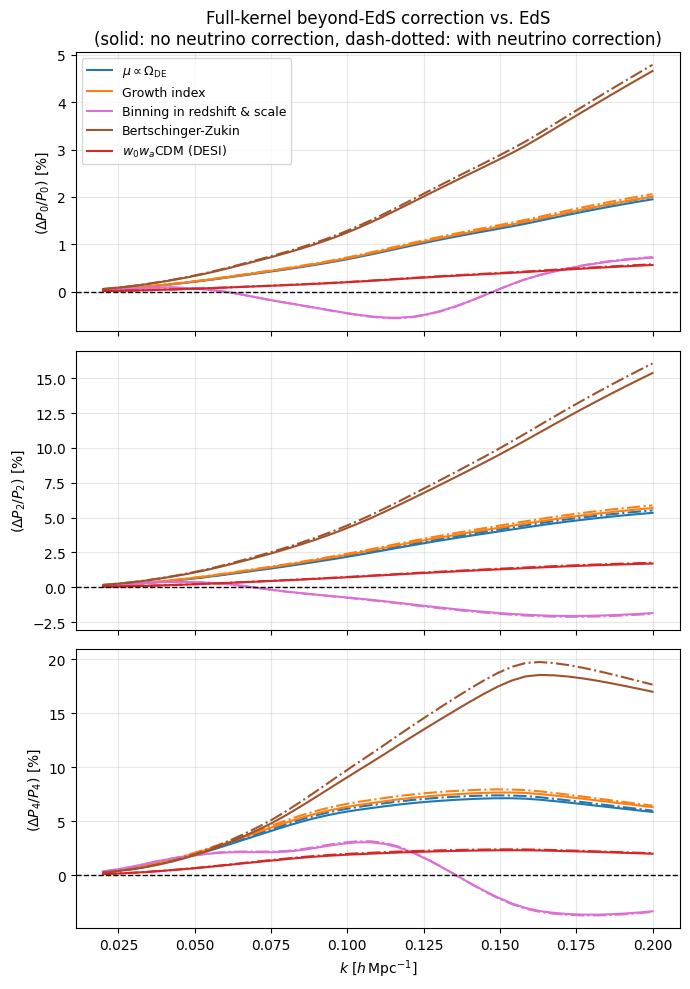

In [11]:
def pct_diff(full, eds):
    return 100.0 * (full - eds) / np.maximum(1.0, np.abs(eds))


pct = {
    key: pct_diff(val["Full"], val["EdS"])
    for key, val in results.items()
}

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
panel_labels = (r"$(\Delta P_0/P_0)$ [%]", r"$(\Delta P_2/P_2)$ [%]", r"$(\Delta P_4/P_4)$ [%]")

for iell, (ax, ylabel) in enumerate(zip(axes, panel_labels)):
    for name in MG_MODELS:
        color = MODEL_COLORS[name]
        ax.plot(np.asarray(k_eval), pct[(name, False)][iell], color=color, ls="-",
                label=name if iell == 0 else None)
        ax.plot(np.asarray(k_eval), pct[(name, True)][iell], color=color, ls="-.")
    ax.axhline(0.0, color="k", ls="--", lw=1.0)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=9, ncol=1, loc="upper left")
axes[-1].set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axes[0].set_title(
    "Full-kernel beyond-EdS correction vs. EdS\n"
    "(solid: no neutrino correction, dash-dotted: with neutrino correction)"
)
fig.tight_layout()
plt.show()

In [12]:
print(f"{'model':30s} {'ell':>3s} {'max|full-EdS| no-nu %':>24s} {'max|full-EdS| with-nu %':>26s}")
for name in MG_MODELS:
    for iell, ell in enumerate(ELLS):
        no_nu = float(np.max(np.abs(pct[(name, False)][iell])))
        with_nu = float(np.max(np.abs(pct[(name, True)][iell])))
        print(f"{name:30s} {ell:3d} {no_nu:24.3f} {with_nu:26.3f}")

model                          ell    max|full-EdS| no-nu %    max|full-EdS| with-nu %
$\mu \propto \Omega_{\rm DE}$    0                    1.951                      2.002
$\mu \propto \Omega_{\rm DE}$    2                    5.339                      5.514
$\mu \propto \Omega_{\rm DE}$    4                    7.117                      7.384
Growth index                     0                    2.008                      2.061
Growth index                     2                    5.682                      5.871
Growth index                     4                    7.647                      7.936
Binning in redshift & scale      0                    0.717                      0.730
Binning in redshift & scale      2                    2.059                      2.121
Binning in redshift & scale      4                    3.663                      3.738
Bertschinger-Zukin               0                    4.661                      4.791
Bertschinger-Zukin               2         

## Presentation figure: $P_0$ and $P_2$ only, stacked with no gap

A two-panel version of the figure above, monopole on top and quadrupole on
the bottom, sharing the x-axis with zero space between the panels (handy for
slides). Plotting code is written out explicitly (not wrapped in a helper
function) so it is easy to tweak in place.

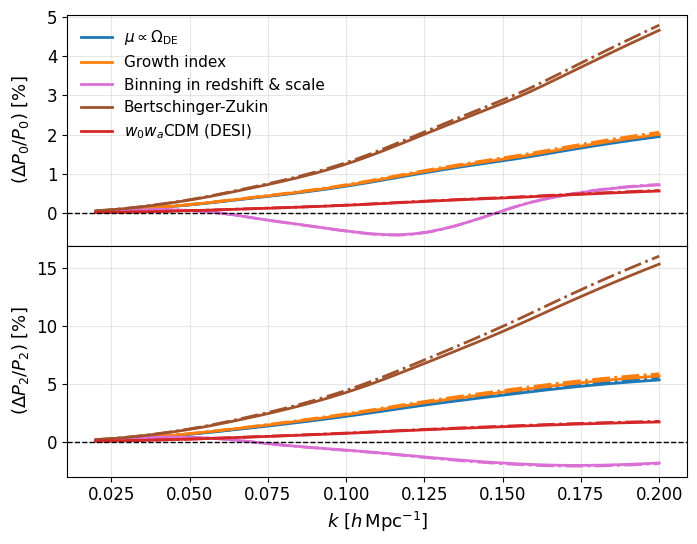

In [13]:
fig, (ax0, ax2) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True,
    gridspec_kw=dict(hspace=0.0),
)

for name in MG_MODELS:
    color = MODEL_COLORS[name]

    ax0.plot(np.asarray(k_eval), pct[(name, False)][0], color=color, ls="-", lw=2, label=name)
    ax0.plot(np.asarray(k_eval), pct[(name, True)][0], color=color, ls="-.", lw=2)

    ax2.plot(np.asarray(k_eval), pct[(name, False)][1], color=color, ls="-", lw=2)
    ax2.plot(np.asarray(k_eval), pct[(name, True)][1], color=color, ls="-.", lw=2)

ax0.axhline(0.0, color="k", ls="--", lw=1.0)
ax2.axhline(0.0, color="k", ls="--", lw=1.0)

ax0.set_ylabel(r"$(\Delta P_0/P_0)$ [%]", fontsize=13)
ax2.set_ylabel(r"$(\Delta P_2/P_2)$ [%]", fontsize=13)
ax2.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$", fontsize=13)

ax0.tick_params(labelsize=12, labelbottom=False)
ax2.tick_params(labelsize=12)

ax0.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

ax0.legend(fontsize=11, ncol=1, loc="upper left", frameon=False)

fig.align_ylabels([ax0, ax2])
plt.show()

## Bertschinger-Zukin only: EdS vs. fkPT-approx vs. full kernels (no neutrino / with neutrino)

A dedicated, single-model comparison: $P_0/P_0^{\rm EdS}$ and $P_2/P_2^{\rm
EdS}$ for the same Bertschinger-Zukin point (`MG_MODELS["Bertschinger-Zukin"]`),
in the same touching-panel style as the presentation figure above, but now
with three beyond-EdS treatments overlaid instead of one:

- **EdS** (`beyond_eds=False`) -- flat black dashed line at 1 (the reference
  every other curve is divided by).
- **bEdS_fkpt_approx_nonu** (`beyond_eds=True, fkpt_approximation=True`, no
  neutrino correction) -- solid blue, divided by the no-nu EdS.
- **bEdS_full_nonu** (`beyond_eds=True, fkpt_approximation=False`, no
  neutrino correction) -- dashed blue, divided by the no-nu EdS.
- **bEdS_full_nu** (`beyond_eds=True, fkpt_approximation=False`, with
  neutrino correction) -- dotted blue, divided by the **with-nu** EdS
  (`EdS_nu_poles`), not the no-nu one -- each curve is normalized against its
  own matching-neutrino-state EdS baseline. This matters: dividing the with-nu
  full-kernel result by the *no*-nu EdS would mix the genuine beyond-EdS
  kernel effect together with the much larger, unrelated $P_{cb}$-vs-$P_m$
  normalization shift, exactly the inconsistency that made this curve look
  offset from `bEdS_full_nonu` in an earlier version of this plot. With the
  matched baseline, this curve is now the direct single-model analogue of the
  presentation figure's with-nu (dash-dot) curve above.

`bEdS_fkpt_approx_nonu` isn't computed anywhere else in the notebook (the
main loop only ever computes `EdS` and the full-kernel `Full`), so it's
computed here. The plotting code itself is written out explicitly (no
helper function) so it's easy to tweak in place.

In [14]:
mg_kwargs_bz = MG_MODELS["Bertschinger-Zukin"]

bEdS_fkpt_approx_nonu_poles, _ = compute_case(
    mg_kwargs_bz, include_nu=False, beyond_eds=True, fkpt_approximation=True,
)

EdS_poles = results[("Bertschinger-Zukin", False)]["EdS"]
EdS_nu_poles = results[("Bertschinger-Zukin", True)]["EdS"]
bEdS_full_nonu_poles = results[("Bertschinger-Zukin", False)]["Full"]
bEdS_full_nu_poles = results[("Bertschinger-Zukin", True)]["Full"]

print("finite:",
      bool(np.all(np.isfinite(EdS_poles))),
      bool(np.all(np.isfinite(EdS_nu_poles))),
      bool(np.all(np.isfinite(bEdS_fkpt_approx_nonu_poles))),
      bool(np.all(np.isfinite(bEdS_full_nonu_poles))),
      bool(np.all(np.isfinite(bEdS_full_nu_poles))))

finite: True True True True True


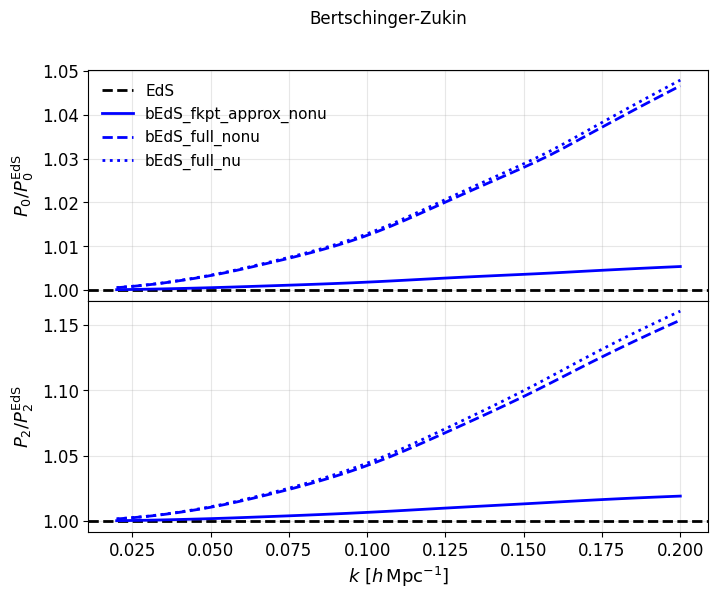

In [15]:
fig, (ax0, ax2) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True,
    gridspec_kw=dict(hspace=0.0),
)

ax0.axhline(1.0, color="black", ls="--", lw=2, label="EdS")
ax0.plot(np.asarray(k_eval), bEdS_fkpt_approx_nonu_poles[0] / EdS_poles[0], color="blue", ls="-", lw=2, label="bEdS_fkpt_approx_nonu")
ax0.plot(np.asarray(k_eval), bEdS_full_nonu_poles[0] / EdS_poles[0], color="blue", ls="--", lw=2, label="bEdS_full_nonu")
ax0.plot(np.asarray(k_eval), bEdS_full_nu_poles[0] / EdS_nu_poles[0], color="blue", ls=":", lw=2, label="bEdS_full_nu")

ax2.axhline(1.0, color="black", ls="--", lw=2)
ax2.plot(np.asarray(k_eval), bEdS_fkpt_approx_nonu_poles[1] / EdS_poles[1], color="blue", ls="-", lw=2)
ax2.plot(np.asarray(k_eval), bEdS_full_nonu_poles[1] / EdS_poles[1], color="blue", ls="--", lw=2)
ax2.plot(np.asarray(k_eval), bEdS_full_nu_poles[1] / EdS_nu_poles[1], color="blue", ls=":", lw=2)

ax0.set_ylabel(r"$P_0 / P_0^{\rm EdS}$", fontsize=13)
ax2.set_ylabel(r"$P_2 / P_2^{\rm EdS}$", fontsize=13)
ax2.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$", fontsize=13)

ax0.tick_params(labelsize=12, labelbottom=False)
ax2.tick_params(labelsize=12)

ax0.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

ax0.legend(fontsize=11, ncol=1, loc="upper left", frameon=False)

fig.align_ylabels([ax0, ax2])
fig.suptitle("Bertschinger-Zukin")
plt.show()

## Hu-Sawicki f(R) (F5) only: EdS vs. fkPT-approx vs. full kernels (no neutrino / with neutrino)

Same idea as the Bertschinger-Zukin section above, now for Hu-Sawicki f(R) at
the standard "F5" literature point ($|f_{R0}| = 10^{-5}$), the same
Hu-Sawicki test point already validated in `compute_mg_multipoles.ipynb`'s
own beyond-EdS section: `fR0_HS=-1.0e-5, beta2=1/6, n_HS=1`. This model is
**not** part of `MG_MODELS` above (adding it there would force a recompute of
the earlier multi-model figures too), so every variant needed here is
computed fresh in this section, with its own `_hs`-suffixed variable names
so it doesn't clobber the Bertschinger-Zukin arrays above.

Unlike the Bertschinger-Zukin plot, this one shows $k P_\ell(k)$ directly for
all three multipoles ($\ell=0,2,4$) rather than ratios to EdS: solid red for
`EdS`, solid blue for `bEdS_fkpt_approx_nonu_hs`, dashed blue for
`bEdS_full_nonu_hs`, dotted blue for `bEdS_full_nu_hs`.

Like Bertschinger-Zukin, Hu-Sawicki f(R) has a genuinely scale-dependent
$\mu(k,\eta)$ (the chameleon mechanism), so `bEdS_fkpt_approx_nonu_hs` and
`bEdS_full_nonu_hs` are expected to show a real, nonzero separation (unlike a
scale-independent model, where the two would agree to solver tolerance) --
see `compute_mg_multipoles.ipynb`'s own note on this.

In [20]:
mg_kwargs_hs = dict(model="HS", fR0_HS=-1.0e-10, beta2=1.0 / 6.0, n_HS=1.0)

EdS_poles_hs, _ = compute_case(mg_kwargs_hs, include_nu=False, beyond_eds=False, fkpt_approximation=True)
EdS_nu_poles_hs, _ = compute_case(mg_kwargs_hs, include_nu=True, beyond_eds=False, fkpt_approximation=True)
bEdS_fkpt_approx_nonu_poles_hs, _ = compute_case(mg_kwargs_hs, include_nu=False, beyond_eds=True, fkpt_approximation=True)
bEdS_full_nonu_poles_hs, _ = compute_case(mg_kwargs_hs, include_nu=False, beyond_eds=True, fkpt_approximation=False)
bEdS_full_nu_poles_hs, _ = compute_case(mg_kwargs_hs, include_nu=True, beyond_eds=True, fkpt_approximation=False)

print("finite:",
      bool(np.all(np.isfinite(EdS_poles_hs))),
      bool(np.all(np.isfinite(EdS_nu_poles_hs))),
      bool(np.all(np.isfinite(bEdS_fkpt_approx_nonu_poles_hs))),
      bool(np.all(np.isfinite(bEdS_full_nonu_poles_hs))),
      bool(np.all(np.isfinite(bEdS_full_nu_poles_hs))))

finite: True True True True True


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

axes[0].plot(np.asarray(k_eval), np.asarray(k_eval) * EdS_poles_hs[0], color="red", ls="-", label="EdS")
axes[0].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_fkpt_approx_nonu_poles_hs[0], color="blue", ls="-", label="bEdS_fkpt_approx_nonu")
axes[0].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nonu_poles_hs[0], color="blue", ls="--", label="bEdS_full_nonu")
axes[0].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nu_poles_hs[0], color="blue", ls=":", label="bEdS_full_nu")
axes[0].set_ylabel(r"$k P_0(k)$")

axes[1].plot(np.asarray(k_eval), np.asarray(k_eval) * EdS_poles_hs[1], color="red", ls="-")
axes[1].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_fkpt_approx_nonu_poles_hs[1], color="blue", ls="-")
axes[1].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nonu_poles_hs[1], color="blue", ls="--")
axes[1].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nu_poles_hs[1], color="blue", ls=":")
axes[1].set_ylabel(r"$k P_2(k)$")

axes[2].plot(np.asarray(k_eval), np.asarray(k_eval) * EdS_poles_hs[2], color="red", ls="-")
axes[2].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_fkpt_approx_nonu_poles_hs[2], color="blue", ls="-")
axes[2].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nonu_poles_hs[2], color="blue", ls="--")
axes[2].plot(np.asarray(k_eval), np.asarray(k_eval) * bEdS_full_nu_poles_hs[2], color="blue", ls=":")
axes[2].set_ylabel(r"$k P_4(k)$")
axes[2].set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")

for ax in axes:
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=9, loc="best")
fig.suptitle(r"Hu-Sawicki f(R), F5 ($f_{R0}=-10^{-5}$)")
fig.tight_layout()
plt.show()